# SUR dynamically adjusted by a Kalman filter

Implements `models.kalman.HourlyKalmanSURModel`: a SURE system (24 hourly equations, "average structural effect" coefficients) where each coefficient receives a dynamic adjustment factor estimated by a Kalman filter, as described on the reference slide:

$$y_{t,h} = \beta_0 + \sum_j \big(\beta^{SUR}_{h,j}\,\beta^{Kalman}_{t,h,j}\big)\,x_{t,h,j} + \varepsilon_{t,h}$$

Filter mechanics taken from the reference notebook ([`kalman_sur1h.ipynb`](https://github.com/PierreRobinSchnepf/Applied-Statistics-ENGIE/blob/main/notebooks/archive/kalman_sur1h.ipynb)): `log1p` target, state = random walk initialized at 1 (no adjustment at the start), standard Kalman update. Deliberate deviation: here the intercept `beta_0` stays **fixed** (no Kalman factor on it), following the formula above — the reference notebook slipped a dynamic intercept into the state.

**Important — what this evaluation compares**: the Kalman predicts *one step ahead* and assimilates the true observation at each step before moving to the next (as in the reference notebook). That is a different regime from a static OLS/SURE that never sees the test period. The relevant comparison here is **SUR (factors frozen at 1) vs Kalman, evaluated under exactly the same one-step-ahead protocol** — not the metrics of the `02_benchmark_ols_sure.ipynb` notebook.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models.dataset import load_dataset, build_hourly_equations, split_train_test, target_series
from models.kalman import HourlyKalmanSURModel
from models import metrics

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

df = load_dataset()
per_hour = build_hourly_equations(df)
train, test = split_train_test(per_hour, test_start="2025-01-01", test_end="2026-01-01")
print(f"train: {len(train[0])} days | test: {len(test[0])} days")

build_hourly_equations: panel balanced over 3055 days (days dropped per hour for imbalance: {0: 10, 1: 14, 2: 5, 3: 13, 4: 14, 5: 14, 6: 14, 7: 14, 8: 14, 9: 14, 10: 14, 11: 14, 12: 14, 13: 14, 14: 14, 15: 14, 16: 14, 17: 14, 18: 14, 19: 14, 20: 14, 21: 13, 22: 13, 23: 13})
train: 2541 days | test: 364 days


In [2]:
model = HourlyKalmanSURModel().fit(train)

y_train, y_test = target_series(train), target_series(test)
# Train predictions: the true one-step-ahead trajectory, computed during fit()
# (starting from the initial state = 1) — not a new predict(train) call, which
# would wrongly resume from the state already converged at the end of training.
sur_train, kalman_train = model.train_sur_pred_, model.train_kalman_pred_
sur_test, kalman_test = model.predict(test)

## 1. Metrics (train / test, one step ahead)

In [3]:
rows = []
for model_name, (train_p, test_p) in {"SUR (frozen)": (sur_train, sur_test), "Kalman": (kalman_train, kalman_test)}.items():
    for split_name, y_true, pred in (("train", y_train, train_p), ("test", y_test, test_p)):
        rows.append({"modele": model_name, "split": split_name, **metrics.evaluate_overall(y_true, pred)})

summary = pd.DataFrame(rows).set_index(["modele", "split"])[["rmse", "mape", "mae", "n"]].round(2)
summary

rmse   mape      mae      n
modele       split                                 
SUR (frozen) train   6965.01  12.20  5341.96  60984
             test   11648.05  29.45  9896.41   8736
Kalman       train   4299.96   7.48  3159.65  60984
             test    3741.70   7.35  2579.80   8736

## 2. Predictions vs actual (2 weeks, 2025 test)

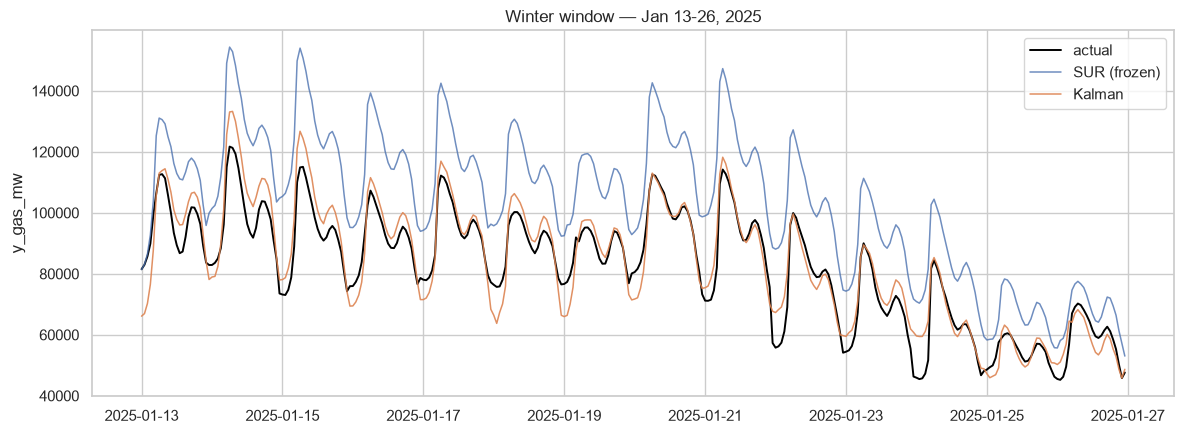

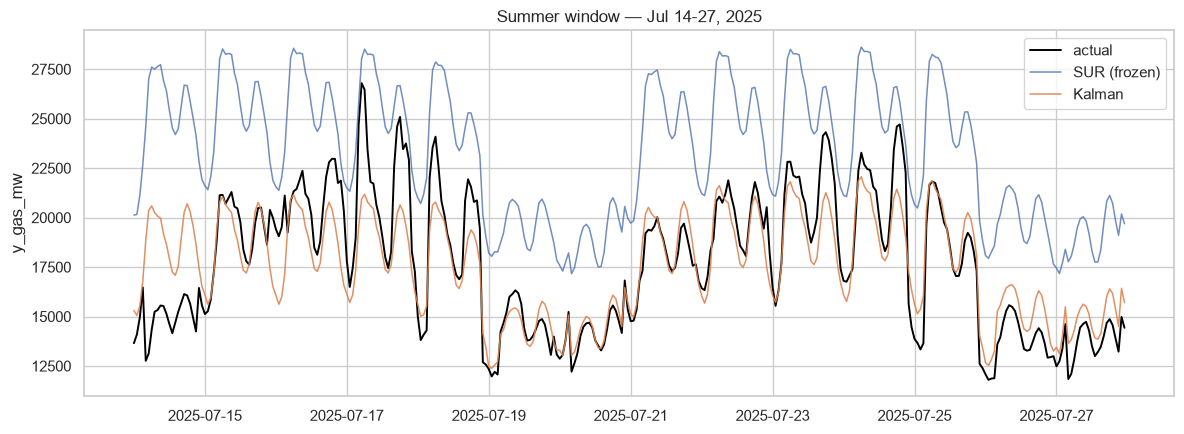

In [4]:
def plot_window(start, end, title):
    actual = metrics.combine_hourly(y_test).loc[start:end]
    sur_line = metrics.combine_hourly(sur_test).loc[start:end]
    kalman_line = metrics.combine_hourly(kalman_test).loc[start:end]

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(actual.index, actual.values, label="actual", color="black", linewidth=1.4)
    ax.plot(sur_line.index, sur_line.values, label="SUR (frozen)", linewidth=1.1, alpha=0.8)
    ax.plot(kalman_line.index, kalman_line.values, label="Kalman", linewidth=1.1, alpha=0.9)
    ax.set_ylabel("y_gas_mw")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_window("2025-01-13", "2025-01-26", "Winter window — Jan 13-26, 2025")
plot_window("2025-07-14", "2025-07-27", "Summer window — Jul 14-27, 2025")

## 3. Cumulative absolute error (2025 test)

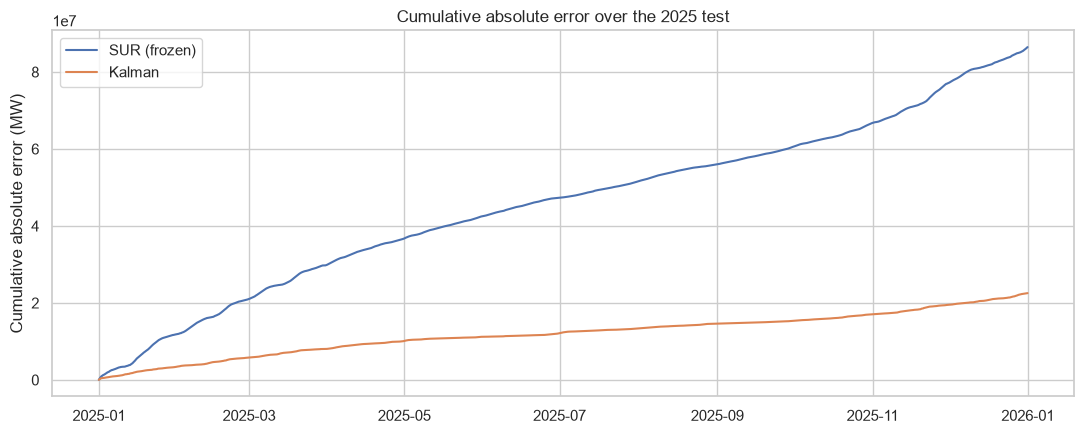

Final cumulative error — SUR: 86,455,064 MW | Kalman: 22,537,152 MW


In [5]:
actual_full = metrics.combine_hourly(y_test)
sur_full = metrics.combine_hourly(sur_test)
kalman_full = metrics.combine_hourly(kalman_test)

sur_cum_err = (sur_full - actual_full).abs().cumsum()
kalman_cum_err = (kalman_full - actual_full).abs().cumsum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sur_cum_err.index, sur_cum_err.values, label="SUR (frozen)")
ax.plot(kalman_cum_err.index, kalman_cum_err.values, label="Kalman")
ax.set_ylabel("Cumulative absolute error (MW)")
ax.set_title("Cumulative absolute error over the 2025 test")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final cumulative error — SUR: {sur_cum_err.iloc[-1]:,.0f} MW | Kalman: {kalman_cum_err.iloc[-1]:,.0f} MW")

## 4. Coefficient evolution (Kalman scale factors, hour 7)
Trajectory of the adjustment factors $\beta^{Kalman}_{t,h,j}$ for hour 7 (train then test). A factor close to 1 means "no departure from the structural SUR"; the 3 thermal-block variables and `is_off_peak_period` are plotted.

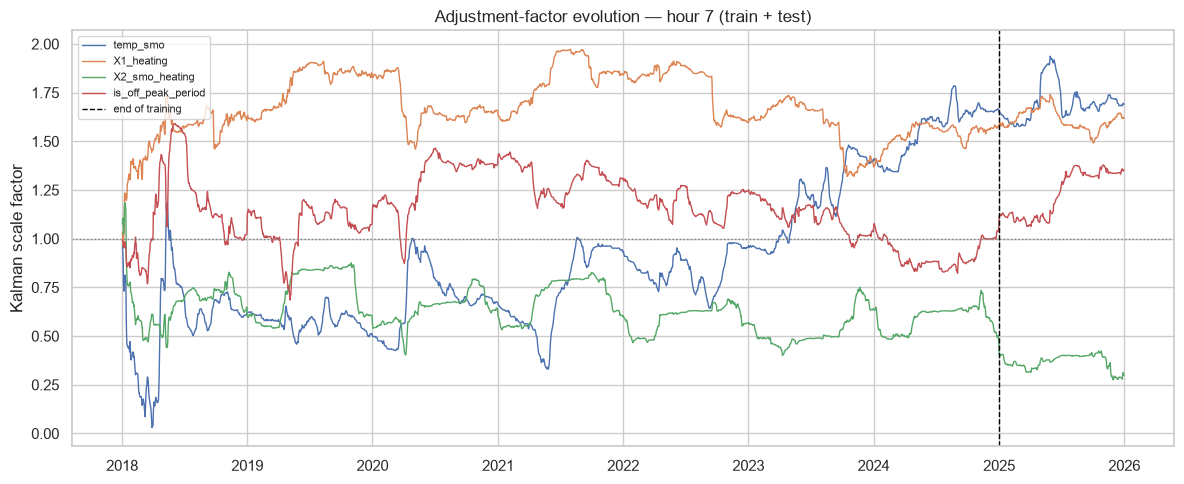

In [6]:
hour_to_inspect = 7
traj = model.full_beta_trajectory(hour_to_inspect)
cols_to_plot = ["temp_smo", "X1_heating", "X2_smo_heating", "is_off_peak_period"]
train_end_date = train[0].index.max()

fig, ax = plt.subplots(figsize=(12, 5))
for col in cols_to_plot:
    ax.plot(traj.index, traj[col].values, label=col, linewidth=1)
ax.axvline(pd.Timestamp(train_end_date), color="black", linestyle="--", linewidth=1, label="end of training")
ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_ylabel("Kalman scale factor")
ax.set_title(f"Adjustment-factor evolution — hour {hour_to_inspect} (train + test)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()